<h1><font color = 'Green'> <center>GIS Applications in Engineering: Assignment 2</h1>
<h3><font color = 'Black'> <center>Washemuzzaman Lajuk (L20606192)</h3>

<h3><font color = 'Blue'> <center>Time-of-Travel (ToT) Capture Zone Delineation – Beaumont, TX</h3>

In this assignment, I developed a Python- and GIS-based workflow to delineate the Time-of-Travel (ToT) capture zones for municipal wells serving the City of Beaumont, Texas. The methodology follows the analytical approach proposed by Ceric and Haitjema (2005), which estimates groundwater capture zones using key aquifer and flow parameters. Using the Northern Gulf Coast Aquifer Groundwater Availability Model (GAM) from the Texas Water Development Board (TWDB), I extracted essential hydrogeologic data for the Chicot and Evangeline formations.

To determine the hydraulic conductivity and porosity, three active wells in Beaumont were used to form a triangular area, and their centroid was computed. The centroid was then overlaid on the SubSurfaceHydroHydraulics.gdb layer from the TWDB GAM dataset in QGIS, using the kh_layers to obtain the hydraulic conductivity and the ib_theta layers to extract porosity. Similarly, to determine the aquifer thickness, the same centroid location was used, and the Model Grid file was imported to identify relevant subsurface layers. The thickness was then calculated by subtracting the bottom elevations of the respective layers.

The capture zones were modeled for travel times of 10, 25, 50, 100, 250, and 500 years, and automatically classified as centric, eccentric, or boat-shaped based on the dimensionless time parameter (T̃). The final geometries were rotated according to the groundwater flow direction and exported as a GeoPackage for visualization in QGIS.

This integrated workflow demonstrates how Python-based hydrogeologic modeling and GIS analysis can be effectively combined to extract aquifer properties and delineate groundwater capture zones, supporting sustainable water resource management and wellhead protection planning.

In [46]:
# Import libraries
import os
import numpy as np
import pandas as pd
import math
import geopandas as gpd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from fiona import listlayers
from sklearn.metrics import mean_squared_error, r2_score
from shapely.geometry import Polygon, Point
from shapely.affinity import rotate, translate

In [47]:
# Set working directory
path = '/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/GIS-Assignment -2'
os.chdir(path)

<h3> <font color = 'Red'> Regional Hydraulic Gradient Calculation

In [48]:
# Load well data prepared using SQL
fname = 'wellsetx.csv'
a = pd.read_csv(fname)
a

,StateWellNumber,Lat,Lon,WellDepth,LSD,Year,County,WL
0,6131901,30.504723,-94.164167,53,111,2021,Hardin,83.4600
1,6133701,30.398333,-94.993889,835,157,2021,Liberty,127.9200
2,6133710,30.409445,-94.961389,365,161,2021,Liberty,80.9625
3,6133712,30.408056,-94.964167,287,160,2021,Liberty,83.7275
4,6133806,30.412778,-94.957223,370,155,2021,Liberty,78.1125
...,...,...,...,...,...,...,...,...
58,6410213,29.845833,-94.810556,166,35,2023,Chambers,1.5000
59,6411611,29.832500,-94.635278,140,27,2022,Chambers,14.4575
60,6413701,29.789722,-94.499167,195,23,2022,Chambers,0.0000
61,6414105,29.833889,-94.341944,164,14,2021,Jefferson,-4.0700


In [49]:
gdf = gpd.GeoDataFrame(
    a,
    geometry=gpd.points_from_xy(a["Lon"], a["Lat"]),
    crs="EPSG:4326"  # WGS84 coordinate system
)

<Axes: >

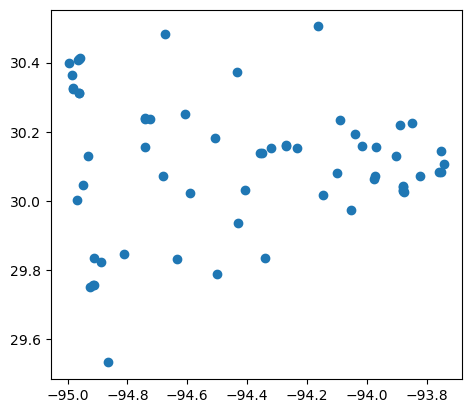

In [50]:
gdf.plot()

In [51]:
gdfaea = gdf.to_crs("EPSG:6350")
gdfaea.head()

,StateWellNumber,Lat,Lon,WellDepth,LSD,Year,County,WL,geometry
0,6131901,30.504723,-94.164167,53,111,2021,Hardin,83.4600,POINT (175849.127 827114.308)
1,6133701,30.398333,-94.993889,835,157,2021,Liberty,127.9200,POINT (96501.776 814108.677)
2,6133710,30.409445,-94.961389,365,161,2021,Liberty,80.9625,POINT (99605.414 815376.314)
3,6133712,30.408056,-94.964167,287,160,2021,Liberty,83.7275,POINT (99340.689 815219.138)
4,6133806,30.412778,-94.957223,370,155,2021,Liberty,78.1125,POINT (100000.866 815750.869)


<Axes: >

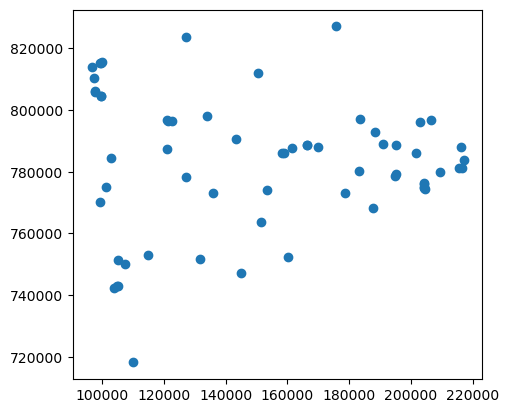

In [52]:
gdfaea.plot()

In [53]:
# Extract X, Y coordinates from geometry
x, y = gdfaea.get_coordinates(ignore_index=True)

# Add coordinate columns to the GeoDataFrame
gdfaea['x'] = gdfaea.geometry.x
gdfaea['y'] = gdfaea.geometry.y
gdfaea['WLM'] = gdfaea.WL*0.3048

# Display first few rows
gdfaea.head()

,StateWellNumber,Lat,Lon,WellDepth,LSD,Year,County,WL,geometry,x,y,WLM
0,6131901,30.504723,-94.164167,53,111,2021,Hardin,83.4600,POINT (175849.127 827114.308),175849.127271,827114.307654,25.438608
1,6133701,30.398333,-94.993889,835,157,2021,Liberty,127.9200,POINT (96501.776 814108.677),96501.775995,814108.677052,38.990016
2,6133710,30.409445,-94.961389,365,161,2021,Liberty,80.9625,POINT (99605.414 815376.314),99605.414130,815376.314264,24.677370
3,6133712,30.408056,-94.964167,287,160,2021,Liberty,83.7275,POINT (99340.689 815219.138),99340.689036,815219.137918,25.520142
4,6133806,30.412778,-94.957223,370,155,2021,Liberty,78.1125,POINT (100000.866 815750.869),100000.865977,815750.869000,23.808690


In [54]:
# Define independent and dependent variables
X = gdfaea[["x", "y"]]       # independent variables
Y = gdfaea["WLM"]            # dependent variable (water level in meters)

# Fit linear regression model
Reg = LinearRegression()
Reg.fit(X, Y)

# Extract coefficients and intercept
a, b = Reg.coef_
c = Reg.intercept_

# Evaluate model performance
r2 = Reg.score(X, Y)
print(f"R² = {r2:.3f}")

R² = 0.706


In [55]:
Reg.coef_

array([-0.00012532,  0.00048201])

In [56]:
# Compute resultant hydraulic gradient magnitude and flow direction (opposite to gradient vector)
i = np.sqrt(a**2 + b**2)         # resultant gradient magnitude
grad_vector = np.array([a, b])   # gradient points toward higher head
flow_vector = -grad_vector       # groundwater flows opposite the gradient

# Compute flow direction angle in degrees (azimuth)
# Convention: 0° = East, 90° = North, measured counterclockwise
flow_angle = np.degrees(np.arctan2(flow_vector[1], flow_vector[0]))
if flow_angle < 0:
    flow_angle += 360

# Display results
print(f"Gradient magnitude (i) = {i:.6e}")
print(f"Flow direction angle = {flow_angle:.2f}° (measured counterclockwise from East)")


Gradient magnitude (i) = 4.980401e-04
Flow direction angle = 284.57° (measured counterclockwise from East)


<h3> <font color = 'Red'> Estimation of groundwater extraction (Q) for the City of Beaumont

In [57]:
fname = 'HistoricalMunicipal.csv'
Q = pd.read_csv(fname)
Q.head()

,Year,TWDB_Survey_No,Organization,Population_Served,Water_Type,Purchasd___Self_Supplied,Region_Used,County_Used,Basin_Used,Source_County,...,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total_Intake__Gallons_
0,2024,5000,A & P WSC,645,Surface Water,Pur,I,PANOLA,SABINE,NaN,...,"1,092,900","1,500,000","1,411,800","1,908,700","1,499,925","2,213,572","2,079,863","1,100,134","1,152,967","16,554,761"
1,2024,15450,ALTO RURAL WSC-BRADFORD MT PLANT,348,Ground Water,SS,I,CHEROKEE,NECHES,CHEROKEE,...,"1,761,100","2,686,600","2,753,400","2,488,500","2,592,000","1,323,900","1,444,700","1,866,300","3,549,000","25,601,400"
2,2024,31200,APPLEBY WSC,"5,481",Ground Water,SS,I,NACOGDOCHES,NECHES,NACOGDOCHES,...,"1,084,000","980,000","1,151,000","2,757,000","2,613,000","2,089,000","2,704,000","1,677,000","921,000","19,189,000"
3,2024,31200,APPLEBY WSC,"5,481",Ground Water,SS,I,NACOGDOCHES,NECHES,NACOGDOCHES,...,"1,758,000","1,550,000","1,550,000","1,758,000","1,684,000","1,751,000","1,569,000","1,631,000","1,547,000","19,963,000"
4,2024,31200,APPLEBY WSC,"5,481",Ground Water,SS,I,NACOGDOCHES,NECHES,NACOGDOCHES,...,"2,490,000","2,184,000","2,635,000","2,996,000","1,322,000","1,729,000","1,460,000","1,442,000","1,664,000","24,381,000"


In [58]:
Q.columns

Index(['Year', 'TWDB_Survey_No', 'Organization', 'Population_Served',
       'Water_Type', 'Purchasd___Self_Supplied', 'Region_Used', 'County_Used',
       'Basin_Used', 'Source_County', 'Source_Basin', 'Aquifer_Source',
       'Surface_Water_Source', 'Seller_Name', 'Active_Wells',
       'Brackish___Saline', 'TWDB_Estimated_Volume',
       'Percent_Treated_Prior_to_Intake', 'Jan', 'Feb', 'Mar', 'Apr', 'May',
       'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
       'Total_Intake__Gallons_'],
      dtype='object')

In [59]:
# Filters for 2023 and 2024
Q12024 = Q[(Q['Year'] == 2024) &
           (Q['Organization'] == 'CITY OF BEAUMONT') &
           (Q['Water_Type'] == 'Ground Water')][['Year', 'Organization', 'Water_Type', 'Total_Intake__Gallons_']]

Q12023 = Q[(Q['Year'] == 2023) &
           (Q['Organization'] == 'CITY OF BEAUMONT') &
           (Q['Water_Type'] == 'Ground Water')][['Year', 'Organization', 'Water_Type', 'Total_Intake__Gallons_']]

Q1 = (
    pd.to_numeric(Q12023['Total_Intake__Gallons_'].str.replace(',', ''), errors='coerce').sum() +
    pd.to_numeric(Q12024['Total_Intake__Gallons_'].str.replace(',', ''), errors='coerce').sum()
) / 2

print(f"Average Groundwater Intake (2023–2024): {Q1:,.0f} gallons/year")


Average Groundwater Intake (2023–2024): 1,104,471,886 gallons/year


In [60]:
# Convert Beaumont average pumping (gallons/year) to cubic meters per second
Q_yr_gal = Q1.mean()                # from your existing code
Q_yr_m3  = Q_yr_gal * 0.00378541    # 1 US gallon = 0.00378541 m³
Q   = Q_yr_m3 / (365 * 24 * 3600)

print(f"Beaumont Average Groundwater Pumping Rate (Q) = {Q:.3e} m³/s")

Beaumont Average Groundwater Pumping Rate (Q) = 1.326e-01 m³/s


<h3> <font color = 'red'> Average Aquifer thickness H Calculation

In [61]:
gdb = "/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/GIS-Assignment -2/GULF_geodatabase/GAM_FileGeodatabase_v4.3.2.gdb"

grid = gpd.read_file(gdb, layer="GULF_grid")
print(grid.columns)


Index(['row', 'col', 'natlRow', 'natlCol', 'top_1', 'bot_1', 'bot_2', 'bot_3',
       'bot_4', 'bot_5', 'bot_6', 'IB_1', 'IB_2', 'IB_3', 'IB_4', 'IB_5',
       'IB_6', 'ZB_1', 'ZB_2', 'ZB_3', 'ZB_4', 'ZB_5', 'ZB_6', 'GHB',
       'DRN_unname', 'DRN_named', 'DRN_Head', 'RIV_named', 'NHD_length',
       'RIV_stage', 'RIV_bot', 'fine_m2', 'fine_m3', 'fine_m4', 'fine_m5',
       'rnb2', 'rnb3', 'rnb4', 'rnb5', 'IC_1', 'GCD', 'GMAnum', 'CNTY_NM',
       'RWPA', 'Shape_Length', 'Shape_Area', 'X', 'Y', 'IB_active',
       'geometry'],
      dtype='object')


In [62]:
grid.head()

,row,col,natlRow,natlCol,top_1,bot_1,bot_2,bot_3,bot_4,bot_5,...,GCD,GMAnum,CNTY_NM,RWPA,Shape_Length,Shape_Area,X,Y,IB_active,geometry
0,1.0,1.0,2988.0,2420.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,None,NaN,None,Brazos G,13123.348500,1.076387e+07,5728491.5,19728914.0,inactive,"MULTIPOLYGON Z (((5726787.08 19730488.826 0, 5..."
1,1.0,2.0,2988.0,2421.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,None,NaN,None,Brazos G,13123.348519,1.076387e+07,5731775.0,19729040.0,inactive,"MULTIPOLYGON Z (((5730070.592 19730614.285 0, ..."
2,1.0,3.0,2988.0,2422.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,None,NaN,None,Brazos G,13123.348856,1.076387e+07,5735058.5,19729166.0,inactive,"MULTIPOLYGON Z (((5733354.107 19730739.694 0, ..."
3,1.0,4.0,2988.0,2423.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,None,NaN,None,Brazos G,13123.349171,1.076387e+07,5738342.0,19729292.0,inactive,"MULTIPOLYGON Z (((5736637.625 19730865.053 0, ..."
4,1.0,5.0,2988.0,2424.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,None,NaN,None,Brazos G,13123.349175,1.076387e+07,5741625.5,19729416.0,inactive,"MULTIPOLYGON Z (((5739921.145 19730990.361 0, ..."


In [63]:
#Load the NGGAM grid
gdb_path = "/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/GIS-Assignment -2/GULF_geodatabase/GAM_FileGeodatabase_v4.3.2.gdb"
grid = gpd.read_file(gdb_path, layer="GULF_grid")

import warnings
warnings.filterwarnings("ignore", message="Measured .* geometry types")

#Compute aquifer thickness for Chicot and Evangeline layers ---
# Thickness (H) = difference between layer top and bottom in feet
grid['H1_ft'] = grid['top_1'] - grid['bot_1']      # Layer 1 (Alluvium)
grid['H2_ft'] = grid['bot_1'] - grid['bot_2']      # Layer 2 (Chicot)
grid['H3_ft'] = grid['bot_2'] - grid['bot_3']      # Layer 3 (Evangeline)

# Convert thickness to meters
grid['H2_m'] = grid['H2_ft'] * 0.3048
grid['H3_m'] = grid['H3_ft'] * 0.3048

In [64]:
# Basic statistics of aquifer thickness (mean, min, max, etc.)
grid[['H2_m', 'H3_m']].describe()

,H2_m,H3_m
count,1.330000e+05,133000.000000
mean,2.979776e+01,52.463728
std,5.125454e+01,90.866492
min,-4.331469e-15,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,4.692314e+01,75.590400
max,2.139696e+02,417.576000


In [65]:
# Average thickness values only ---
H_Chicot = grid['H2_m'].mean()
H_Evangeline = grid['H3_m'].mean()
# Display results
print("Average Chicot Aquifer Thickness:", H_Chicot, "m")
print("Average Evangeline Aquifer Thickness:", H_Evangeline, "m")

Average Chicot Aquifer Thickness: 29.79775588440122 m
Average Evangeline Aquifer Thickness: 52.46372800264061 m


In [66]:
f2name = 'WellMain.txt'
wells = pd.read_csv(f2name,sep='|',encoding='ISO-8859-1', low_memory = False)
wells.head()

,StateWellNumber,County,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer,...,WellReportTrackingNumber,PluggingReportTrackingNumber,USGSSiteNumber,TCEQSourceId,GCDWellNumber,OwnerWellNumber,OtherWellNumber,PreviousStateWellNumber,CreatedDate,LastUpdateDate
0,140301,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2004-05-18,2025-05-13
1,140302,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGDP,"Ogallala Formation, Dakota Group and Purgatoir...",58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,2003-12-23,2022-12-02
2,140601,Dallam,Canadian,1,A - Panhandle,North Plains GCD,211DKOP,Dakota Group and Purgatoire Formation,23,Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-01,2020-01-16
3,140901,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLL,Ogallala Formation,21,Ogallala,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1966-08-30,2018-03-27
4,140902,Dallam,Canadian,1,A - Panhandle,North Plains GCD,121OGLD,Ogallala Formation and Dakota Group,58,Ogallala/Rita Blanca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-10-01,2020-01-16


In [67]:
Hardinwl1 = wells[wells['County'].isin(['Hardin'])]

In [68]:
f3name = 'WaterLevelsMajor.txt'
waterLevels = pd.read_csv(f3name,sep='|',encoding='ISO-8859-1', low_memory = False)

In [69]:
Hardinwl2 = waterLevels[(waterLevels['County'].isin(['Hardin'])) & (waterLevels['MeasuringAgency'].isin (['Municipal Water Agency or PWS Corporation']))]

In [70]:
Hardinjoined = Hardinwl1.merge(Hardinwl2, on='StateWellNumber', how='inner')
Hardinjoined.head()

,StateWellNumber,County_x,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer_x,...,LandElevation,LandElevationMethod,WaterElevation,MeasurementNumber,MeasuringAgency,MethodOfMeasurement,Remarks_y,Comments,CreatedDate_y,LastUpdateDate_y
0,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,94.00,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2003-12-02,2003-12-02
1,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,86.75,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2004-11-29,2004-11-29
2,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,91.10,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2006-02-06,2006-02-06
3,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,86.10,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2006-12-01,2006-12-01
4,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,80.90,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2008-02-01,2008-02-01


In [71]:
HJ_Beaumont = Hardinjoined.drop_duplicates(subset=['StateWellNumber'])
HJ_Beaumont.head()

,StateWellNumber,County_x,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer_x,...,LandElevation,LandElevationMethod,WaterElevation,MeasurementNumber,MeasuringAgency,MethodOfMeasurement,Remarks_y,Comments,CreatedDate_y,LastUpdateDate_y
0,6129803,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Interpolated From Topo Map,94.0,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2003-12-02,2003-12-02
8,6129805,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,117.0,Digital Elevation Model -DEM,85.0,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2014-03-12,2014-03-12
9,6155104,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,37.0,Interpolated From Topo Map,-48.5,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2002-12-01,2002-12-01
18,6155203,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,25.0,Interpolated From Topo Map,-160.5,1,Municipal Water Agency or PWS Corporation,Electric Line,Pumping-level measurement,NaN,NaN,NaN
32,6155206,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,35.0,Interpolated From Topo Map,-30.2,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,NaN,NaN


In [72]:
HJ_Active = HJ_Beaumont[
    (HJ_Beaumont['WellUse'].str.strip().str.lower() == 'public supply'.lower()) &
    (HJ_Beaumont['Owner'].str.strip().str.lower() == 'city of beaumont well'.lower())
]
HJ_Active.head()

,StateWellNumber,County_x,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer_x,...,LandElevation,LandElevationMethod,WaterElevation,MeasurementNumber,MeasuringAgency,MethodOfMeasurement,Remarks_y,Comments,CreatedDate_y,LastUpdateDate_y


In [73]:
HJ_Active = HJ_Beaumont[
    (HJ_Beaumont['WellUse'].str.strip().str.lower() == 'public supply'.lower()) &
    (HJ_Beaumont['Owner'].str.strip().isin([
        "City of Beaumont well #3",
        "City of Beaumont New Well #2",
        "City of Beaumont Loeb #1"
    ]))
]

HJ_Active.head()

,StateWellNumber,County_x,RiverBasin,GMA,RWPA,GCD,AquiferCode,AquiferCodeDescription,AquiferId,Aquifer_x,...,LandElevation,LandElevationMethod,WaterElevation,MeasurementNumber,MeasuringAgency,MethodOfMeasurement,Remarks_y,Comments,CreatedDate_y,LastUpdateDate_y
9,6155104,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,37.0,Interpolated From Topo Map,-48.5,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2002-12-01,2002-12-01
39,6155207,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,112CHCT,Chicot Aquifer,15,Gulf Coast,...,26.0,Digital Elevation Model -DEM,-60.0,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,2014-04-08,2014-04-08
40,6155513,Hardin,Neches,14,I - East Texas,Southeast Texas GCD,121EVGL,Evangeline Aquifer,15,Gulf Coast,...,24.0,Interpolated From Topo Map,-40.3,1,Municipal Water Agency or PWS Corporation,Electric Line,NaN,NaN,NaN,NaN


In [74]:
# Export HJ_Active wells to CSV
HJ_Active.to_csv('HJ_Active_Wells_in_Beaumont.csv', index=False)

In [75]:
# Create coordinate list from the active wells
coords = list(zip(HJ_Active["LongitudeDD"], HJ_Active["LatitudeDD"]))

# Ensure polygon is closed
if coords[0] != coords[-1]:
    coords.append(coords[0])

#  Create polygon and compute centroid
poly = Polygon(coords)
centroid = poly.centroid

#  Build a DataFrame that includes the three wells + centroid
records = []

# Add each well vertex with specific aquifer names
for i, (lon, lat) in enumerate(coords[:-1], start=1): 
    if i == 1 or i == 3:
        aquifer = "Evangeline Aquifer"
    elif i == 2:
        aquifer = "Chicot Aquifer"
   
    
    records.append({
        "Name": f"Well_{i}",
        "Type": "Well Vertex",
        "Aquifer": aquifer,
        "Longitude": lon,
        "Latitude": lat
    })

# Add centroid
records.append({
    "Name": "Triangle_Centroid",
    "Type": "Centroid",
    "Aquifer": "Computed Centroid",
    "Longitude": centroid.x,
    "Latitude": centroid.y
})


# Convert to DataFrame
export_df = pd.DataFrame(records)

# Save as CSV (QGIS-ready, WGS 84)
export_df.to_csv("HJ_Active_Centroid.csv", index=False)

# Optional: preview
print(export_df)


                Name         Type             Aquifer  Longitude   Latitude
0             Well_1  Well Vertex  Evangeline Aquifer -94.210556  30.240834
1             Well_2  Well Vertex      Chicot Aquifer -94.196389  30.221944
2             Well_3  Well Vertex  Evangeline Aquifer -94.191945  30.207778
3  Triangle_Centroid     Centroid   Computed Centroid -94.199630  30.223519


<h3> <font color = 'red'> Hydraulic Conductivity (K) and Porosity (n)

For the hydraulic conductivity and porosity analysis, three active wells in Beaumont were used to form a triangular area, and their centroid was computed. In QGIS, the centroid was overlaid on the SubSurfaceHydroHydraulics.gdb layer from the TWDB GAM dataset. The kh_layers were used to obtain the hydraulic conductivity (K) value of 24.11 ft/day, and the ib_theta layers were used to extract the porosity value of 0.26042.

In [76]:
# Convert hydraulic conductivity from ft/day to m/s
KQGIS = 24.11 * 3.52778e-6
K = 2*KQGIS
print(K)

0.0001701095516


<h3> <font color = 'red'> Exact Aquifer thickness (H) Calculation

To determine the exact aquifer thickness (H), three active wells in Beaumont were used to form a triangular area, and their centroid was computed. The centroid was then overlaid on the Model Grid layers, where the wells were identified within bot3 and bot4. By subtracting the elevations (877 ft – 692 ft), the aquifer thickness was calculated as 185 ft.

In [77]:
display(HJ_Active[['StateWellNumber', 'WellDepth']])

,StateWellNumber,WellDepth
9,6155104,765.0
39,6155207,802.0
40,6155513,800.0


In [78]:
HinFT = 877-692 #ft
H = HinFT*0.3048  #m
H

56.388000000000005

<h3> <font color = 'red'> Capture Zone Delineation

In [79]:
#Parameters

K = 0.00017011    # m/s hydraulic conductivity
i = 4.980401e-4 # -
H = 56.388       # m
n = 0.25        # -
Q = 1.326e-1    # m³/s Beaumont Average Groundwater Pumping Rate
theta_deg = 284.57  # (Flow direction angle - measured counterclockwise from East)

In [80]:
# Convert centroid from lon/lat to projected CRS (use Texas South Central)
well_gdf = gpd.GeoDataFrame(
    pd.DataFrame({'Name': ['Centroid']}),
    geometry=gpd.points_from_xy([-94.19963], [30.22352]),
    crs="EPSG:4326"
)
well_gdf = well_gdf.to_crs("EPSG:6350")   # NAD83 / Texas South Central (m)
cx, cy = well_gdf.geometry.x.iloc[0], well_gdf.geometry.y.iloc[0]

In [81]:
# Derived parameters per Ceric & Haitjema (2005)
Qo = K * H * i                      # ambient flow per unit width (m²/s)
Ls = Q / (2 * math.pi * Qo)         # stagnation distance (m)
To = (n * H * Q) / (2 * math.pi * Qo**2)  # characteristic time (s)

In [82]:
# FUNCTION
def solve_Lu_tilde(Tt, tol=1e-12):
    low, high = 0.0, max(2*Tt + 1, 50)
    for _ in range(100):
        mid = 0.5 * (low + high)
        f = mid - Tt * math.log1p(mid)
        if f > 0:
            high = mid
        else:
            low = mid
        if abs(high - low) < tol:
            break
    return 0.5 * (low + high)

def solve_Ld_tilde(Tt, tol=1e-12):
    low, high = 1e-9, 0.999999
    for _ in range(100):
        mid = 0.5 * (low + high)
        f = mid + Tt * math.log(1 - mid)
        if f > 0:
            high = mid
        else:
            low = mid
        if abs(high - low) < tol:
            break
    return 0.5 * (low + high)

def shift_upgradient(geom, d, theta_deg):
    rad = math.radians(theta_deg + 180.0)
    return translate(geom, xoff=d * math.cos(rad), yoff=d * math.sin(rad))

def make_circle(R):
    return Point(0, 0).buffer(R, resolution=256)

# --- time horizons ---
times = [10, 25, 50, 100, 250, 500]
results, geoms = [], []

for t_years in times:
    T = t_years * 365.25 * 24 * 3600
    Tt = T / To

    # Always compute centric radius
    R_centric = 1.1543 * math.sqrt(Q * T / (math.pi * H * n))

    if Tt < 0.1:
        # Centric circle
        geom = make_circle(R_centric)
        shape = "centric_circle"

    elif Tt <= 1.0:
        # Stable eccentric circle (prevent collapse)
        Lu_t = solve_Lu_tilde(Tt)
        Ld_t = solve_Ld_tilde(Tt)
        Rm = 0.5 * (Lu_t + Ld_t) * Ls
        dm = 0.5 * (Lu_t - Ld_t) * Ls

        # Enforce a minimum radius using centric-circle baseline
        R_stable = max(Rm, R_centric)
        geom = shift_upgradient(make_circle(R_stable), dm, theta_deg)
        shape = "eccentric_circle"

    else:
        # Boat envelope
        Lu_t = solve_Lu_tilde(Tt)
        Lu = Lu_t * Ls
        width = 2 * Ls
        height = 2 * Lu
        poly = Point(0, 0).buffer(1, resolution=128)
        poly_scaled = Polygon([(x * width, y * height) for x, y in np.array(poly.exterior.coords)])
        geom = shift_upgradient(poly_scaled, Lu / 2, theta_deg)
        shape = "boat_envelope"

    # Rotate and translate geometry
    geom = rotate(geom, theta_deg, origin=(0, 0), use_radians=False)
    geom = translate(geom, xoff=cx, yoff=cy)

    # Store results
    results.append({
        "Time (yrs)": t_years,
        "T̃": Tt,
        "Shape": shape,
        "area_m2": geom.area,
        "Area (km2)": geom.area / 1e6
    })
    geoms.append(geom)

In [83]:
# Create GeoDataFrame
gdf = gpd.GeoDataFrame(results, geometry=geoms, crs="EPSG:6350")
gdf.to_file("Beaumont_CaptureZones.gpkg", layer="capture_zones", driver="GPKG")
gdf.drop(columns="geometry").to_csv("Beaumont_CaptureZones.csv", index=False)
print(gdf[["Time (yrs)","T̃","Shape","Area (km2)"]])


   Time (yrs)        T̃             Shape  Area (km2)
0          10  0.024209    centric_circle    3.955082
1          25  0.060522    centric_circle    9.887704
2          50  0.121045  eccentric_circle   19.775408
3         100  0.242089  eccentric_circle   39.550817
4         250  0.605223  eccentric_circle   98.877042
5         500  1.210446     boat_envelope  109.990346
